# 🎯 AI Resume Screening & Ranking System

This project builds an **AI-powered resume screening system** that evaluates and ranks resumes against a job description using Natural Language Processing (NLP).

The system simulates how modern **HR-tech recruitment platforms automatically shortlist candidates**.

### Key Features

• Resume preprocessing  
• NLP-based skill extraction  
• TF-IDF similarity matching  
• Job role selection system  
• Candidate ranking  
• Score interpretation  
• Skill gap analysis  
• Skill recommendations  
• Category visualization  
• Resume word cloud  
• CSV and PDF resume support

## 📦 Step 1 — Import Libraries

We import the libraries used for:

• data processing  
• natural language processing  
• machine learning  
• visualization  
• PDF resume extraction

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import spacy
import pdfplumber
import os

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

## 🔤 Step 2 — Load NLP Models

We load the NLP tools required for text cleaning and skill extraction.

In [2]:
nltk.download("stopwords")
nltk.download("wordnet")

nlp = spacy.load("en_core_web_sm")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Amrutha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Amrutha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 📄 Step 3 — Extract Text from PDF

Many resumes are uploaded as PDF files.  
This function extracts text from PDF resumes so they can be analyzed.

In [3]:
def extract_text_from_pdf(file):

    text = ""

    with pdfplumber.open(file) as pdf:

        for page in pdf.pages:

            page_text = page.extract_text()

            if page_text:
                text += page_text

    return text

## 📂 Step 4 — Load Resume Dataset

The dataset contains:## 📂 Step 4 — Load Resume Dataset

The dataset contains two important columns:

• **Category** → job domain of the resume  
• **Resume_str** → actual resume text


In [4]:
df = pd.read_csv("Resume.csv")

df = df[["Resume_str", "Category"]]

df.head()


,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


## 🧹 Step 5 — Text Cleaning

Resume text is cleaned to improve NLP analysis by:

• converting to lowercase  
• removing punctuation  
• removing stopwords  
• lemmatizing words

In [5]:
def clean_text(text):

    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["clean_resume"] = df["Resume_str"].apply(clean_text)

## 🔍 Step 6 — Skill Extraction

We detect technical skills appearing in resumes using a predefined skill dictionary.

In [59]:
# -------------------------------
# Skill List
# -------------------------------

skills = [

# Programming Languages
"python","java","c","c++","c#","javascript","typescript","r","matlab","go","ruby","php","scala","kotlin","swift",

# Data Science / ML
"machine learning","deep learning","data science","nlp","computer vision",
"predictive modeling","data mining","statistical modeling","feature engineering",

# ML Libraries
"scikit learn","tensorflow","keras","pytorch","xgboost","lightgbm","catboost",

# Data Analysis
"pandas","numpy","scipy","statistics","data analysis","data visualization",

# BI Tools
"tableau","power bi","excel","looker","qlikview",

# Databases
"sql","mysql","postgresql","mongodb","sqlite","oracle","cassandra","redis",

# Big Data
"hadoop","spark","pyspark","hive","kafka",

# Cloud Platforms
"aws","azure","google cloud","gcp","cloud computing",

# DevOps
"docker","kubernetes","jenkins","git","github","gitlab","ci cd",

# Web Development
"html","css","react","angular","node.js","flask","django","fastapi","spring boot",

# Data Engineering
"etl","data pipeline","airflow","databricks",

# Visualization Libraries
"matplotlib","seaborn","plotly","ggplot",

# Other Tools
"linux","bash","shell scripting","jira","agile","scrum"

]

# -------------------------------
# Skill Extraction Function
# -------------------------------

import re

def extract_skills(text):

    text = text.lower()
    found = set()

    for skill in skills:

        pattern = r"\b" + re.escape(skill) + r"\b"

        if re.search(pattern, text):
            found.add(skill)

    return list(found)

df["skills"] = df["clean_resume"].apply(extract_skills)

## 📄 Step 7 — Select Job Role

We provide example job descriptions for different roles.

The user selects a role and the corresponding job description is used for resume screening.

In [60]:
# ----------------------------------------
# Job Role Descriptions
# ----------------------------------------

job_descriptions = {

"Data Scientist": """
Looking for a Data Scientist with strong experience in Python,
Machine Learning, Deep Learning, NLP, SQL, Pandas, NumPy,
TensorFlow, and predictive modeling.
""",

"Machine Learning Engineer": """
Seeking a Machine Learning Engineer with expertise in Python,
TensorFlow, PyTorch, Deep Learning, NLP, and model deployment.
Experience with Docker and Kubernetes is preferred.
""",

"Data Analyst": """
Hiring a Data Analyst with experience in SQL, Excel,
Power BI, Tableau, Python, Pandas, and data visualization.
""",

"Software Developer": """
Looking for a Software Developer skilled in Java, Python,
JavaScript, SQL, Git, and web development frameworks.
""",

"Data Engineer": """
Seeking a Data Engineer experienced in ETL pipelines,
Spark, Hadoop, SQL, Airflow, and cloud platforms such as AWS or Azure.
""",

"Business Intelligence Analyst": """
Looking for a BI Analyst with expertise in Tableau,
Power BI, SQL, Excel, and data visualization.
""",

"AI Engineer": """
Hiring an AI Engineer with strong knowledge in Python,
Deep Learning, NLP, Computer Vision, TensorFlow, and PyTorch.
""",

"Backend Developer": """
Looking for a Backend Developer with experience in
Python, Node.js, Django, Flask, FastAPI, SQL, and REST APIs.
""",

"Frontend Developer": """
Seeking a Frontend Developer skilled in HTML, CSS,
JavaScript, React, Angular, and modern UI frameworks.
""",

"Cloud Engineer": """
Looking for a Cloud Engineer experienced in AWS,
Azure, Google Cloud, Docker, Kubernetes, and cloud infrastructure.
""",

"DevOps Engineer": """
Hiring a DevOps Engineer with expertise in Docker,
Kubernetes, Jenkins, CI/CD pipelines, Git, and Linux.
""",

"Big Data Engineer": """
Seeking a Big Data Engineer with experience in
Hadoop, Spark, Kafka, Hive, and distributed data processing.
""",

"Database Administrator": """
Looking for a DBA skilled in MySQL, PostgreSQL,
Oracle, MongoDB, database optimization, and backup management.
"""
}

# ----------------------------------------
# Step 1: Display Available Job Roles
# ----------------------------------------
# This section prints all the job roles stored in the
# job_descriptions dictionary so the user knows
# which roles are available for selection.

print("Available Job Roles:\n")

for role in job_descriptions:
    print("-", role)


# ----------------------------------------
# Step 2: Safe User Input for Role Selection
# ----------------------------------------
# The while loop ensures that the user enters a valid
# job role from the available list.
# If the input is incorrect, the program asks the user again.

while True:

    # Take user input and standardize format
    selected_role = input("\nEnter job role: ").strip().title()

    # Check if the role exists in our dictionary
    if selected_role in job_descriptions:
        break
    else:
        print("\nInvalid role. Please try again.")


# ----------------------------------------
# Step 3: Retrieve the Corresponding Job Description
# ----------------------------------------
# Once a valid role is selected, we fetch the job
# description from the dictionary.

job_description = job_descriptions[selected_role]


# ----------------------------------------
# Step 4: Display Selected Role and Description
# ----------------------------------------
# This prints the final job role and the associated
# job description that will be used for resume screening.

print("\nSelected Job Role:", selected_role)
print("\nJob Description:\n")
print(job_description)

Available Job Roles:

- Data Scientist
- Machine Learning Engineer
- Data Analyst
- Software Developer
- Data Engineer
- Business Intelligence Analyst
- AI Engineer
- Backend Developer
- Frontend Developer
- Cloud Engineer
- DevOps Engineer
- Big Data Engineer
- Database Administrator



Enter job role:  data scientist



Selected Job Role: Data Scientist

Job Description:


Looking for a Data Scientist with strong experience in Python,
Machine Learning, Deep Learning, NLP, SQL, Pandas, NumPy,
TensorFlow, and predictive modeling.



## 📊 Step 8 — TF-IDF Vectorization

TF-IDF converts text into numerical vectors that represent the importance of words.

In [69]:
vectorizer = TfidfVectorizer(stop_words="english")

tfidf_matrix = vectorizer.fit_transform(
df["clean_resume"].tolist() + [job_description]
)

## 📏 Step 9 — Cosine Similarity

Cosine similarity measures how similar each resume is to the job description.

In [70]:
cosine_scores = cosine_similarity(
tfidf_matrix[-1],
tfidf_matrix[:-1]
)

df["tfidf_score"] = cosine_scores.flatten()

## 🧠 Step 10 — Skill Match Score

We calculate how many job description skills appear in each resume.

In [71]:
jd_skills = extract_skills(clean_text(job_description))

def skill_overlap(candidate):

    matched = set(candidate).intersection(set(jd_skills))

    return len(matched)/len(jd_skills) if len(jd_skills)>0 else 0

df["skill_score"] = df["skills"].apply(skill_overlap)

## 🏆 Step 11 — Final Candidate Score

The final candidate score evaluates how well each resume matches the selected job role.

This score combines two important factors:

• **70% TF-IDF similarity**  
Measures how similar the resume text is to the job description using NLP vectorization.

• **30% Skill Overlap**  
Measures how many required job skills appear in the candidate's resume.

### Final Score Formula

Final Score = (0.7 × TF-IDF Similarity) + (0.3 × Skill Match)

This weighted scoring system prioritizes overall textual similarity while also ensuring that key technical skills are considered during candidate ranking.

In [72]:
df["final_score"] = (
0.7 * df["tfidf_score"] +
0.3 * df["skill_score"]
)

## 📊 Step 12 — Score Interpretation

Candidates are classified according to their match score.

In [73]:
def interpret_score(score):

    if score >= 0.7:
        return "Strong Fit"

    elif score >= 0.4:
        return "Partial Fit"

    else:
        return "Weak Fit"

df["fit_level"] = df["final_score"].apply(interpret_score)

## 📋 Step 13 — Candidate Ranking

Candidates are ranked based on their final score.

In [74]:
ranked = df.sort_values(
    by="final_score",
    ascending=False
)

ranked.reset_index(drop=True, inplace=True)
ranked = ranked.copy()

## 🧠 Step 14 — Skill Gap Analysis

The system identifies matched skills and missing skills for each candidate.

In [75]:
def skill_gap(candidate):

    matched=list(set(candidate).intersection(set(jd_skills)))
    missing=list(set(jd_skills)-set(candidate))

    return matched,missing

ranked["matched_skills"], ranked["missing_skills"] = zip(
*ranked["skills"].apply(skill_gap)
)

## 💡 Step 15 — Skill Recommendations

Based on missing skills, the system suggests what candidates should learn.

In [76]:
# ----------------------------------------
# Skill Learning Resources
# ----------------------------------------

skill_resources = {

# Programming
"python": "Practice Python projects and build data analysis scripts",
"java": "Learn Java fundamentals and object-oriented programming",
"javascript": "Build web applications using JavaScript and frameworks",
"c++": "Practice problem solving and system programming",

# Data Science
"machine learning": "Learn ML algorithms using Scikit-learn",
"deep learning": "Study TensorFlow or PyTorch and build neural networks",
"data science": "Work on end-to-end data science projects",
"nlp": "Learn NLP using spaCy and NLTK",
"computer vision": "Study OpenCV and deep learning models",

# Libraries
"pandas": "Practice data cleaning and analysis using Pandas",
"numpy": "Learn numerical computing with NumPy",
"scikit learn": "Build ML models using Scikit-learn",
"tensorflow": "Build neural networks using TensorFlow",
"keras": "Develop deep learning models with Keras",
"pytorch": "Learn PyTorch for advanced deep learning",

# Databases
"sql": "Practice SQL queries and database design",
"mysql": "Learn MySQL database management",
"postgresql": "Practice advanced SQL with PostgreSQL",
"mongodb": "Learn NoSQL databases using MongoDB",

# Visualization
"tableau": "Create dashboards using Tableau",
"power bi": "Build business analytics dashboards with Power BI",
"matplotlib": "Visualize data using Matplotlib",
"seaborn": "Create statistical plots using Seaborn",
"plotly": "Build interactive data visualizations",

# Big Data
"hadoop": "Learn distributed storage and processing with Hadoop",
"spark": "Process large datasets using Apache Spark",
"pyspark": "Learn big data analytics using PySpark",
"kafka": "Understand real-time data streaming with Kafka",

# Cloud
"aws": "Learn cloud deployment using AWS services",
"azure": "Practice cloud infrastructure using Microsoft Azure",
"google cloud": "Deploy ML models using Google Cloud",

# DevOps
"docker": "Containerize applications using Docker",
"kubernetes": "Learn container orchestration using Kubernetes",
"jenkins": "Implement CI/CD pipelines using Jenkins",
"git": "Practice version control using Git and GitHub",

# Web Development
"flask": "Build web applications using Flask",
"django": "Develop scalable web applications with Django",
"fastapi": "Create APIs using FastAPI",
"react": "Build modern frontend interfaces using React",
"angular": "Develop frontend applications using Angular",

# Data Engineering
"etl": "Learn ETL pipeline design and data workflows",
"airflow": "Schedule data pipelines using Apache Airflow",
"databricks": "Learn big data analytics using Databricks"
}


# ----------------------------------------
# Recommendation Function
# ----------------------------------------

def generate_recommendations(missing):

    rec = []

    for skill in missing:
        if skill in skill_resources:
            rec.append(skill_resources[skill])

    return rec


# ----------------------------------------
# Apply Recommendation System
# ----------------------------------------

ranked["skill_recommendations"] = ranked["missing_skills"].apply(generate_recommendations)


# ----------------------------------------
# Preview Results
# ----------------------------------------

ranked[["missing_skills", "skill_recommendations"]].head()

,missing_skills,skill_recommendations
0,"[tensorflow, nlp, deep learning, numpy]","[Build neural networks using TensorFlow, Learn..."
1,"[tensorflow, machine learning, deep learning, ...","[Build neural networks using TensorFlow, Learn..."
2,"[tensorflow, deep learning, numpy, predictive ...","[Build neural networks using TensorFlow, Study..."
3,"[machine learning, deep learning, numpy, predi...","[Learn ML algorithms using Scikit-learn, Study..."
4,"[tensorflow, deep learning, numpy, predictive ...","[Build neural networks using TensorFlow, Study..."


## 📈 Step 16 — Candidate Score Visualization

We visualize the top candidate scores.

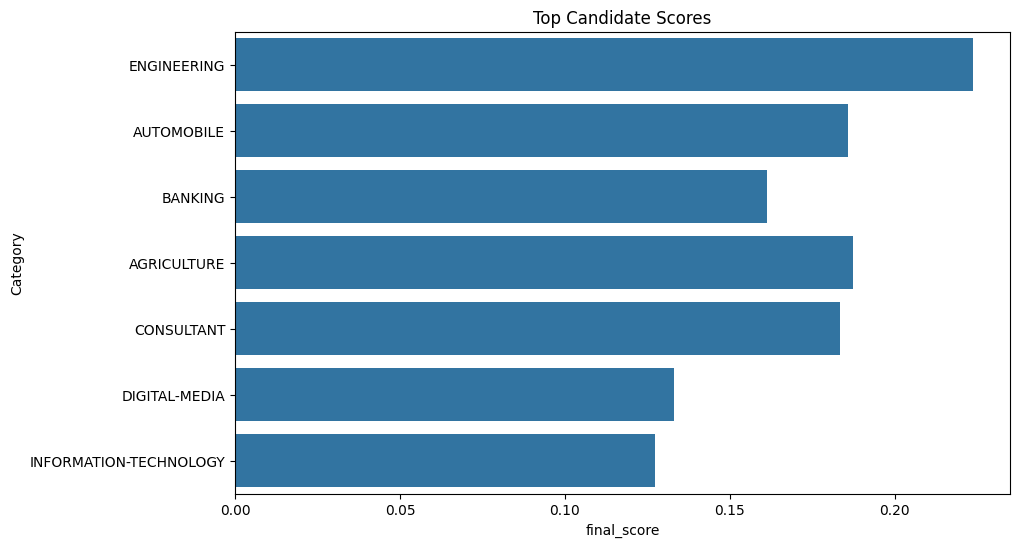

In [77]:
plt.figure(figsize=(10,6))

sns.barplot(
x=ranked["final_score"][:10],
y=ranked["Category"][:10],
errorbar=None    
)

plt.title("Top Candidate Scores")

plt.show()

## 🔥 Step 17 — Skill Coverage Heatmap

This heatmap visualizes how well the **top ranked candidates** match the required job skills.

Each row represents a candidate and each column represents a skill extracted from the job description.

Value meaning:

- **1 (dark color)** → candidate has the skill  
- **0 (light color)** → skill missing

This helps recruiters quickly understand **which candidates possess the required skills**.

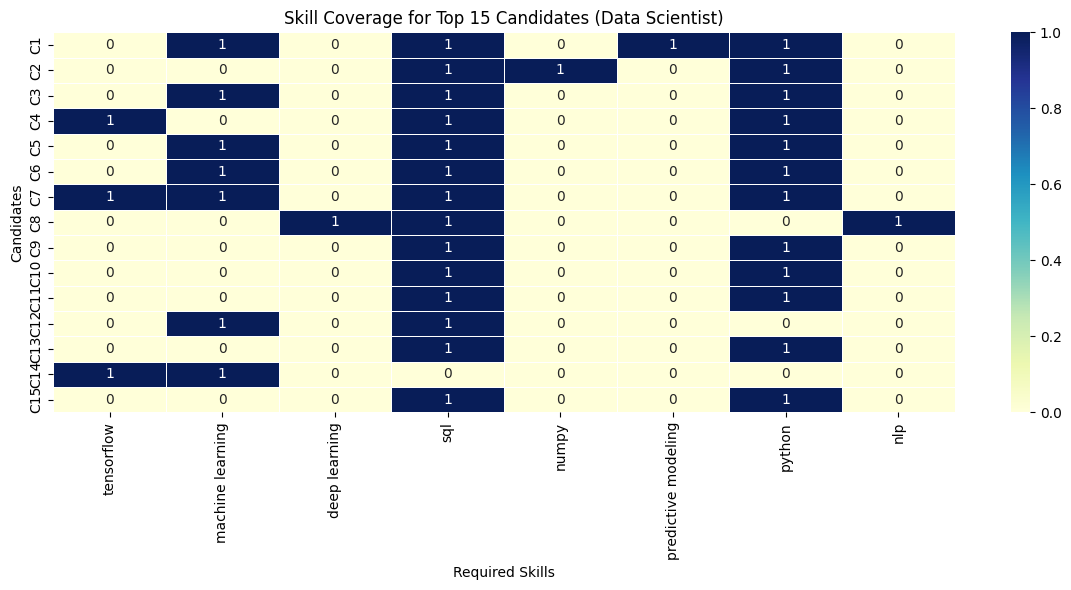

In [78]:
top_n = 15
top_candidates = ranked.head(top_n)

skill_matrix = []

for s in top_candidates["skills"]:
    
    row = []
    
    for skill in jd_skills:
        row.append(1 if skill in s else 0)
    
    skill_matrix.append(row)

skill_df = pd.DataFrame(skill_matrix, columns=jd_skills)

skill_df.index = [f"C{i+1}" for i in range(len(skill_df))]

plt.figure(figsize=(12,6))

sns.heatmap(
    skill_df,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=True
)

plt.title(f"Skill Coverage for Top {top_n} Candidates ({selected_role})")
plt.xlabel("Required Skills")
plt.ylabel("Candidates")

plt.tight_layout()
plt.show()

## ☁️ Step 18 — Resume Keyword Word Cloud

Word clouds highlight frequently occurring keywords in resumes.

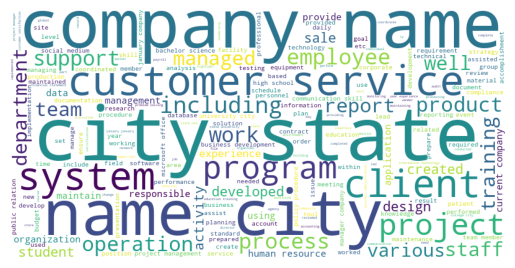

In [82]:
text=" ".join(df["clean_resume"])

wordcloud=WordCloud(
width=800,
height=400,
background_color="white"
).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

## 📊 Top Skills Distribution in Resumes

This visualization shows the **most common skills appearing in the resume dataset**.

Understanding skill distribution helps recruiters and analysts identify:

• most popular technologies  
• dominant technical domains  
• trends in candidate skill sets

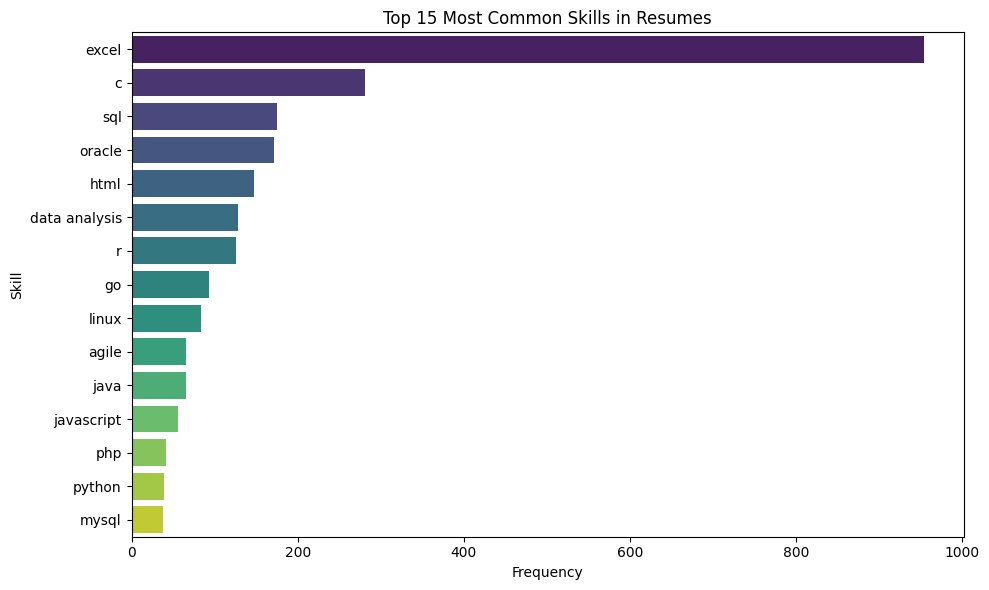

In [80]:
# ----------------------------------------
# Extract All Skills From Dataset
# ----------------------------------------

all_skills = []

for skill_list in df["skills"]:
    all_skills.extend(skill_list)


# ----------------------------------------
# Count Skill Frequency
# ----------------------------------------

skill_counts = pd.Series(all_skills).value_counts().head(15)


# ----------------------------------------
# Plot Top Skills
# ----------------------------------------

plt.figure(figsize=(10,6))

sns.barplot(
    x=skill_counts.values,
    y=skill_counts.index,
    hue=skill_counts.index,
    palette="viridis",
    legend=False
)

plt.title("Top 15 Most Common Skills in Resumes")
plt.xlabel("Frequency")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

## 🎯 Conclusion

In this project, we built an **AI-powered Resume Screening and Ranking System** using Natural Language Processing (NLP) techniques. The system simulates how modern recruitment platforms automatically analyze resumes and shortlist candidates for a specific job role.

The workflow of the system includes:

• **Resume preprocessing** to clean and normalize unstructured resume text  
• **Skill extraction using regex-based NLP techniques** to accurately identify technical skills  
• **Job description parsing** to determine the required skills for a selected role  
• **TF-IDF vectorization** to represent resumes and job descriptions as numerical vectors  
• **Cosine similarity calculation** to measure how closely a resume matches the job description  
• **Skill overlap analysis** to identify how many required skills appear in the candidate’s resume  

The **final candidate score** is calculated using a weighted scoring approach:

**Final Score = (0.7 × TF-IDF Similarity) + (0.3 × Skill Match)**

This scoring mechanism prioritizes overall resume relevance while also ensuring that **critical technical skills are considered during candidate ranking**.

Using this system, recruiters can:

✔ Automatically **rank candidates based on job relevance**  
✔ **Identify missing skills** in resumes  
✔ **Shortlist the most suitable applicants faster**  
✔ Reduce manual resume screening effort  

This project demonstrates how **machine learning and NLP can support decision-making in recruitment systems**, making the hiring process more efficient and data-driven.

The approach implemented here represents a **simplified version of real-world AI recruitment platforms**, but the same concepts can be extended further using advanced NLP models, semantic embeddings, and large-scale resume datasets.